<a href="https://colab.research.google.com/github/rekhadhorigol/face-recognition-eigenfaces/blob/main/face_recognition_using_eigen_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib scikit-learn pillow opencv-python-headless -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import zipfile
from PIL import Image
from sklearn.decomposition import PCA
from google.colab import files
import urllib.request
import warnings
warnings.filterwarnings('ignore')

!pip install deepface -q

from deepface import DeepFace

IMG_SIZE = (64, 64)

CASCADE_PATH = "haarcascade_frontalface_default.xml"
if not os.path.exists(CASCADE_PATH):
    url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url, CASCADE_PATH)

face_cascade = cv2.CascadeClassifier(CASCADE_PATH)

# warm up DeepFace - downloads Facenet model(CNN model) once (~90MB)
print("Loading Facenet model (downloads once, ~90MB)...")
_ = DeepFace.represent(
    np.zeros((100,100,3), dtype=np.uint8),
    model_name='Facenet',
    enforce_detection=False
)
print("All ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.8 MB/s eta 0:00:00
26-04-15 10:54:25 - Directory /root/.deepface has been created
26-04-15 10:54:25 - Directory /root/.deepface/weights has been created
Loading Facenet model (downloads once, ~90MB)...
26-04-15 10:54:29 - 🔗 facenet_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5 to /root/.deepface/weights/facenet_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 117MB/s]


All ready


In [ ]:
def extract_face(img_bgr, pad=0.25):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    for scale, neighbors in [(1.1, 5), (1.05, 3), (1.3, 2)]:
        faces = face_cascade.detectMultiScale(
            gray, scaleFactor=scale, minNeighbors=neighbors,
            minSize=(30, 30), flags=cv2.CASCADE_SCALE_IMAGE
        )
        if len(faces) > 0:
            break

    h_img, w_img = gray.shape

    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        pad_x = int(w * pad)
        pad_y = int(h * pad)
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(w_img, x + w + pad_x)
        y2 = min(h_img, y + h + pad_y)
        detected = True
    else:
        print("No face detected (using centre-top crop)")
        cx1 = int(w_img * 0.15); cx2 = int(w_img * 0.85)
        x1, y1, x2, y2 = cx1, 0, cx2, int(h_img * 0.55)
        detected = False

    # crop both BGR (for DeepFace) and gray (for display)
    crop_bgr  = img_bgr[y1:y2, x1:x2]
    crop_gray = gray[y1:y2, x1:x2]

    # eye alignment
    resized_gray = cv2.resize(crop_gray, IMG_SIZE)
    eye_cascade  = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_eye.xml')
    eyes = eye_cascade.detectMultiScale(
        resized_gray, scaleFactor=1.1, minNeighbors=5, minSize=(8,8))

    if len(eyes) >= 2:
        eyes = sorted(eyes, key=lambda e: e[0])[:2]
        cx1_e = eyes[0][0] + eyes[0][2]//2; cy1_e = eyes[0][1] + eyes[0][3]//2
        cx2_e = eyes[1][0] + eyes[1][2]//2; cy2_e = eyes[1][1] + eyes[1][3]//2
        angle = np.degrees(np.arctan2(cy2_e - cy1_e, cx2_e - cx1_e))
        M     = cv2.getRotationMatrix2D(
            ((cx1_e+cx2_e)//2, (cy1_e+cy2_e)//2), angle, 1.0)
        resized_gray = cv2.warpAffine(resized_gray, M, IMG_SIZE)
        crop_bgr     = cv2.warpAffine(
            cv2.resize(crop_bgr, IMG_SIZE), M, IMG_SIZE)
    else:
        crop_bgr = cv2.resize(crop_bgr, IMG_SIZE)

    clahe        = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
    resized_gray = clahe.apply(resized_gray)

    return resized_gray, crop_bgr, detected

In [ ]:
print("Upload your dataset.zip file:")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall("dataset_extracted")
print(f"Extracted: {zip_filename}\n")

training_data  = {}   # { person: [128-dim DeepFace embedding] }
raw_images     = {}   # { person: [gray PIL images for display] }
detection_log  = {}

extract_root = "dataset_extracted"
for root, dirs, _ in os.walk(extract_root):
    dirs.sort()
    for folder in sorted(dirs):
        folder_path = os.path.join(root, folder)
        image_files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))
        ])
        if not image_files:
            continue

        person = folder
        training_data[person] = []
        raw_images[person]    = []
        detection_log[person] = {"detected": 0, "fallback": 0}
        print(f"Processing {person}...")

        for img_file in image_files:
            img_path = os.path.join(folder_path, img_file)
            img_bgr  = cv2.imread(img_path)
            if img_bgr is None:
                continue

            face_gray, face_bgr, detected = extract_face(img_bgr)
            detection_log[person]["detected" if detected else "fallback"] += 1

            # DeepFace embedding - 128-dim vector encoding facial identity
            try:
                emb = DeepFace.represent(
                    face_bgr,
                    model_name='Facenet',
                    enforce_detection=False
                )[0]['embedding']
                training_data[person].append(np.array(emb))
            except Exception as e:
                print(f" Embedding failed for {img_file}: {e}")
                continue

            raw_images[person].append(Image.fromarray(face_gray))

persons = sorted(training_data.keys())
print(f"\nLoaded {len(persons)} persons with DeepFace embeddings:")
for p in persons:
    d = detection_log[p]
    print(f"   -- {p}: {len(training_data[p])} embeddings  "
          f"({d['detected']} face-detected, {d['fallback']} fallback)")

Upload your dataset.zip file:


Saving dataset_final.zip to dataset_final.zip
Extracted: dataset_final.zip

Processing Milana_Nagaraj...
Processing Sidharth_Malhotra...
Processing Taylor_Swift...
No face detected (using centre-top crop)

Loaded 3 persons with DeepFace embeddings:
   -- Milana_Nagaraj: 10 embeddings  (10 face-detected, 0 fallback)
   -- Sidharth_Malhotra: 10 embeddings  (10 face-detected, 0 fallback)
   -- Taylor_Swift: 10 embeddings  (9 face-detected, 1 fallback)


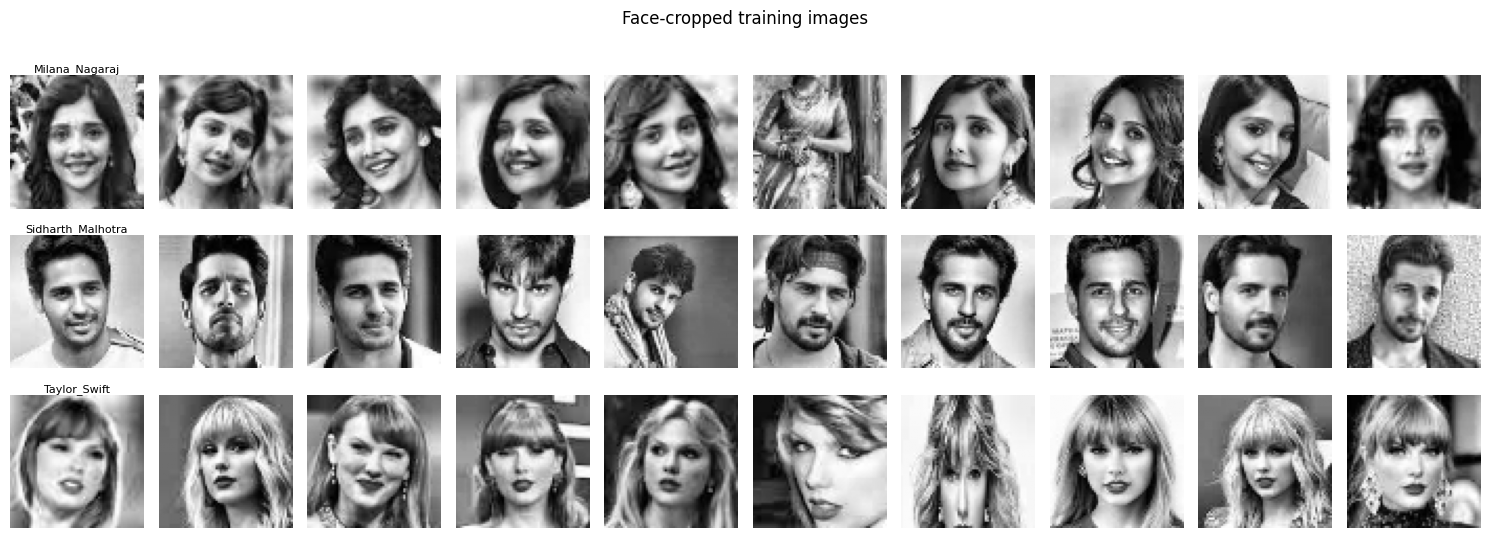

In [ ]:
# We'll now see only face crops, no clothing part visible
cols = 10
fig, axes = plt.subplots(len(persons), cols, figsize=(cols * 1.5, len(persons) * 1.8))
if len(persons) == 1:
    axes = [axes]

for r, person in enumerate(persons):
    imgs = raw_images[person]
    for c in range(cols):
        ax = axes[r][c] if len(persons) > 1 else axes[c]
        if c < len(imgs):
            ax.imshow(imgs[c], cmap='gray')
            ax.set_title(person if c == 0 else '', fontsize=8, pad=2)
        ax.axis('off')

plt.suptitle("Face-cropped training images", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Stack DeepFace embeddings into matrix A

all_vectors = []
all_labels  = []

for person in persons:
    for vec in training_data[person]:
        all_vectors.append(vec)
        all_labels.append(person)

A = np.array(all_vectors)    # shape: (n, 128)
labels = np.array(all_labels)

mean_face = A.mean(axis=0)
A_centered = A - mean_face

print(f"Embedding matrix A : {A.shape}  (images × 128-dim Facenet features)")
print("No raw pixel matrix needed - DeepFace handles feature extraction")

Embedding matrix A : (30, 128)  (images × 128-dim Facenet features)
No raw pixel matrix needed - DeepFace handles feature extraction


 PCA on embeddings - 20 components
 Variance explained: 97.3%


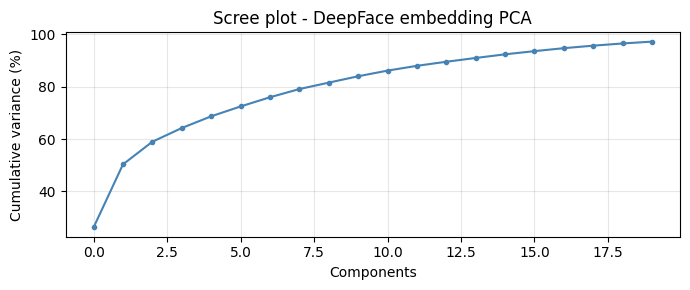

In [ ]:
# PCA on DeepFace embeddings

N_COMPONENTS = min(len(all_vectors) - 1, 20)

pca = PCA(n_components=N_COMPONENTS, whiten=False, svd_solver='full')
pca.fit(A_centered)

eigenfaces = pca.components_
explained  = pca.explained_variance_ratio_

print(f" PCA on embeddings - {N_COMPONENTS} components")
print(f" Variance explained: {explained.sum()*100:.1f}%")

plt.figure(figsize=(7, 3))
plt.plot(np.cumsum(explained)*100, marker='o', markersize=3,
         linewidth=1.5, color='steelblue')
plt.xlabel("Components"); plt.ylabel("Cumulative variance (%)")
plt.title("Scree plot - DeepFace embedding PCA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

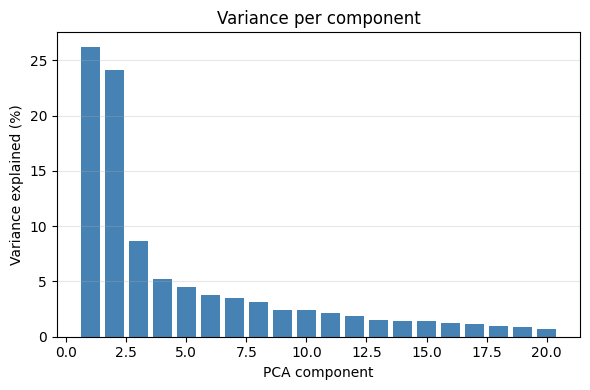

In [ ]:
# Visualise what PCA captured from the DeepFace embeddings

fig, axes = plt.subplots(1, 1, figsize=(6, 4)) # Changed to a single subplot

# Left: variance per component
axes.bar(range(1, N_COMPONENTS+1), explained*100,
            color='steelblue', edgecolor='none')
axes.set_xlabel("PCA component")
axes.set_ylabel("Variance explained (%)")
axes.set_title("Variance per component")
axes.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

--- Outlier removal per person ---
  Milana_Nagaraj  kept 9/10  (removed 1 outlier crop(s))
  Sidharth_Malhotra  kept 9/10  (removed 1 outlier crop(s))
  Taylor_Swift  kept 9/10  (removed 1 outlier crop(s))

Removed crops for Milana_Nagaraj:


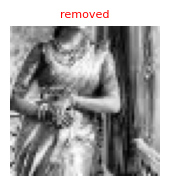


Removed crops for Sidharth_Malhotra:


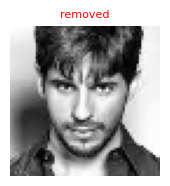


Removed crops for Taylor_Swift:


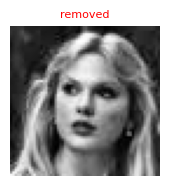


Gallery built from clean crops.


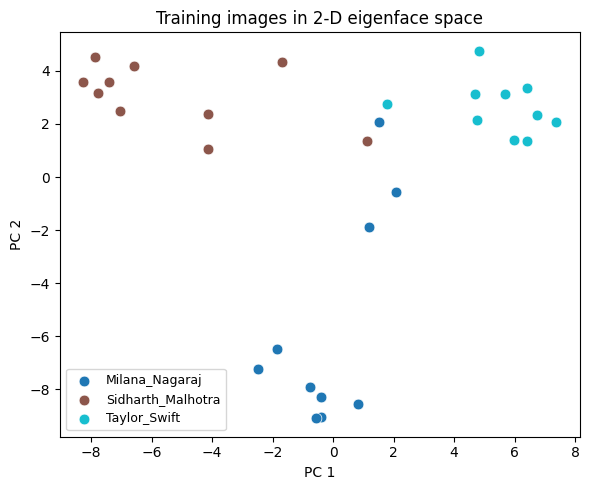

In [ ]:
# Project training images, remove outlier crops, build robust gallery

projections = pca.transform(A_centered)

# Find and remove outlier crops per person
# Outlier = projection that's far from rest of that person's cluster
clean_projections = {}
outlier_log = {}

for person in persons:
    idx = np.where(labels == person)[0]     # global row indices in A
    projs = projections[idx]                # that person's projections
    centroid = projs.mean(axis=0)
    dists = np.linalg.norm(projs - centroid, axis=1)

    threshold = dists.mean() + 1.5 * dists.std()
    keep_mask = dists <= threshold             # boolean over THIS person's images only

    # Map back to global indices correctly
    kept_global    = idx[keep_mask]
    removed_global = idx[~keep_mask]

    clean_projections[person] = projs[keep_mask]
    outlier_log[person] = {
        "total" : len(idx),
        "kept" : keep_mask.sum(),
        "removed": (~keep_mask).sum(),
        "indices": removed_global              # correct global indices now
    }

print("--- Outlier removal per person ---")
for p in persons:
    o = outlier_log[p]
    print(f"  {p:<12}  kept {o['kept']}/{o['total']}  "
          f"({'removed ' + str(o['removed']) + ' outlier crop(s)' if o['removed'] else 'all clean'})")

# Show removed crops so you know what got dropped
for p in persons:
    removed_idx_global = outlier_log[p]["indices"]
    if len(removed_idx_global) == 0:
        continue
    print(f"\nRemoved crops for {p}:")
    fig, axes = plt.subplots(1, len(removed_idx_global), figsize=(len(removed_idx_global)*1.8, 2))
    if len(removed_idx_global) == 1:
        axes = [axes]
    for ax, global_idx_to_remove in zip(axes, removed_idx_global):
        person_label = labels[global_idx_to_remove]
        # Calculate the local index of the removed image within raw_images[person_label]
        local_idx_for_person = sum(1 for i in range(global_idx_to_remove) if labels[i] == person_label)

        # Display the actual image from raw_images
        img_to_display = raw_images[person_label][local_idx_for_person]
        ax.imshow(img_to_display, cmap='gray')
        ax.set_title("removed", fontsize=8, color='red')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Build gallery from clean projections only
gallery = {p: clean_projections[p].mean(axis=0) for p in persons}

# Also store all individual clean projections for per-image NN
all_clean_projs = []
all_clean_labels = []
for p in persons:
    idx = np.where(labels == p)[0]
    keep = outlier_log[p]["indices"]          # outlier indices
    for i, proj in zip(idx, projections[idx]):
        if i not in keep:                     # skip outliers
            all_clean_projs.append(proj)
            all_clean_labels.append(p)

all_clean_projs  = np.array(all_clean_projs)
all_clean_labels = np.array(all_clean_labels)

print("\nGallery built from clean crops.")

# 2-D scatter
from sklearn.decomposition import PCA as PCA2D
pca2  = PCA2D(n_components=2)
proj2 = pca2.fit_transform(projections)
clrs  = plt.cm.tab10(np.linspace(0, 1, len(persons)))

plt.figure(figsize=(6, 5))
for i, person in enumerate(persons):
    idx = np.where(labels == person)[0]
    plt.scatter(proj2[idx, 0], proj2[idx, 1], label=person,
                color=clrs[i], s=60, edgecolors='white', linewidths=0.5)
plt.legend(fontsize=9)
plt.title("Training images in 2-D eigenface space")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

Upload your test face image:


Saving abc.jpg to abc.jpg
Face detected: yes

Per-person threshold calibration:
  Person         Mean    Std    Min  Threshold
  Milana_Nagaraj   67.2   22.1   22.8       35.0%
  Sidharth_Malhotra   61.8   23.0    2.8       35.0%
  Taylor_Swift   75.0   10.9   49.8       58.7%


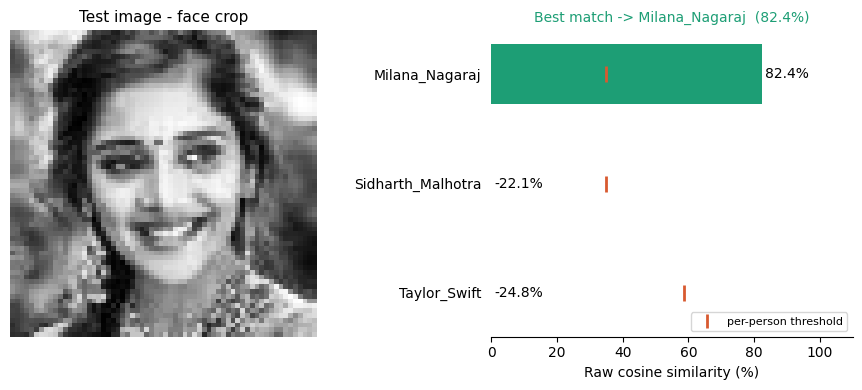


Identified as : Milana_Nagaraj  (82.4%)

All raw scores vs per-person thresholds:
  Milana_Nagaraj  score  82.4%  threshold  35.0%  PASS <-- best match
  Sidharth_Malhotra  score -22.1%  threshold  35.0%  FAIL
  Taylor_Swift  score -24.8%  threshold  58.7%  FAIL


In [ ]:
print("Upload your test face image:")
test_uploaded = files.upload()

test_content = list(test_uploaded.values())[0]
arr = np.frombuffer(test_content, np.uint8)
img_bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
face_gray, face_bgr, detected = extract_face(img_bgr)
print(f"Face detected: {'yes' if detected else 'fallback crop'}")

test_emb = np.array(DeepFace.represent(
    face_bgr, model_name='Facenet', enforce_detection=False
)[0]['embedding'])

test_centered   = test_emb - mean_face
test_projection = pca.transform(test_centered.reshape(1, -1))[0]

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

centroid_cos = {p: cosine_sim(test_projection, gallery[p]) for p in persons}

nn_cos = {}
for p in persons:
    idx = np.where(labels == p)[0]
    kept_idx = [i for i in idx if i not in outlier_log[p]["indices"]]
    sims = [cosine_sim(test_projection, projections[i]) for i in kept_idx]
    nn_cos[p] = max(sims)

combined     = {p: 0.6 * centroid_cos[p] + 0.4 * nn_cos[p] for p in persons}
similarities = {p: combined[p] * 100 for p in persons}

best_match = max(similarities, key=similarities.get)
best_sim   = similarities[best_match]
sorted_p   = sorted(similarities, key=similarities.get, reverse=True)

# Per-person threshold calibration
# each person's threshold = their own training score distribution
# so a person with naturally lower scores isn't unfairly penalised
per_person_thresholds = {}
print("\nPer-person threshold calibration:")
print(f"  {'Person':<12} {'Mean':>6} {'Std':>6} {'Min':>6} {'Threshold':>10}")

for p in persons:
    idx = np.where(labels == p)[0]
    kept_idx = [i for i in idx if i not in outlier_log[p]["indices"]]

    person_scores = []
    for i in kept_idx:
        c_cos = cosine_sim(projections[i], gallery[p])
        other = [j for j in kept_idx if j != i]
        n_cos = max([cosine_sim(projections[i], projections[j])
                     for j in other]) if other else c_cos
        score = (0.6 * c_cos + 0.4 * n_cos) * 100
        person_scores.append(score)

    person_scores = np.array(person_scores)
    # threshold = mean - 1.5*std per person (to reduce false accepts)
    thresh = person_scores.mean() - 1.5 * person_scores.std()
    thresh = max(thresh, 35)   # safety floor
    per_person_thresholds[p] = thresh

    print(f"  {p:<12} {person_scores.mean():>6.1f} "
          f"{person_scores.std():>6.1f} "
          f"{person_scores.min():>6.1f} "
          f"{thresh:>10.1f}%")

# Decision: best match only accepted if it clears ITS OWN threshold
best_threshold = per_person_thresholds[best_match]
is_unknown = best_sim < best_threshold

# Plot
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(face_gray, cmap='gray')
axes[0].set_title("Test image - face crop", fontsize=11)
axes[0].axis('off')

bar_colors = ['#B4B2A9'] * len(persons) if is_unknown else \
             ['#1D9E75' if p == best_match else '#B4B2A9'
              for p in sorted_p[::-1]]
axes[1].barh(sorted_p[::-1],
             [similarities[p] for p in sorted_p[::-1]],
             color=bar_colors, edgecolor='none', height=0.55)

# Draw each person's threshold as a small tick on their bar
for p in sorted_p:
    bar_y    = sorted_p[::-1].index(p)
    p_thresh = per_person_thresholds[p]
    axes[1].plot(p_thresh, bar_y, marker='|', color='#D85A30',
                 markersize=12, markeredgewidth=2)
    axes[1].text(max(similarities[p], 0) + 0.8, bar_y,
                 f"{similarities[p]:.1f}%", va='center', fontsize=10)

axes[1].set_xlim(0, 110)
axes[1].set_xlabel("Raw cosine similarity (%)")

# Legend for threshold marker
from matplotlib.lines import Line2D
axes[1].legend(
    handles=[Line2D([0], [0], marker='|', color='#D85A30',
                    markersize=10, markeredgewidth=2, linestyle='none',
                    label='per-person threshold')],
    fontsize=8, loc='lower right'
)

title_text  = (f"Unknown person  "
               f"(best {best_sim:.1f}% < {best_match} threshold "
               f"{best_threshold:.1f}%)") \
              if is_unknown else \
              f"Best match -> {best_match}  ({best_sim:.1f}%)"
title_color = '#D85A30' if is_unknown else '#1D9E75'
axes[1].set_title(title_text, fontsize=10, color=title_color)
axes[1].spines[['top', 'right', 'left']].set_visible(False)
axes[1].tick_params(left=False)
plt.tight_layout()
plt.show()

if is_unknown:
    print(f"\nUnknown person - no confident match found")
    print(f"   Best score {best_sim:.1f}% ({best_match}) is below "
          f"that person's threshold of {best_threshold:.1f}%")
else:
    print(f"\nIdentified as : {best_match}  ({best_sim:.1f}%)")

print(f"\nAll raw scores vs per-person thresholds:")
for p in sorted_p:
    thresh = per_person_thresholds[p]
    status = "PASS" if similarities[p] >= thresh else "FAIL"
    marker = " <-- best match" if p == best_match and not is_unknown else ""
    print(f"  {p:<12}  score {similarities[p]:5.1f}%  "
          f"threshold {thresh:5.1f}%  {status}{marker}")

--- Face detection quality per person ---

  Milana_Nagaraj  10/10 detected  (100%)  ██████████
  Sidharth_Malhotra  10/10 detected  (100%)  ██████████
  Taylor_Swift  9/10 detected  (90%)  █████████░

All training crops (check for blank/wrong crops):


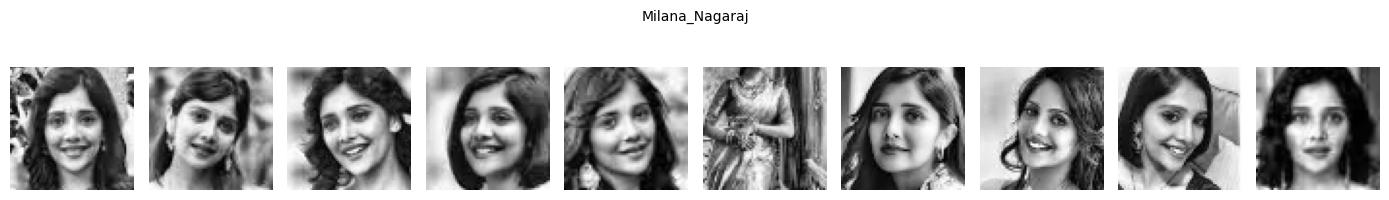

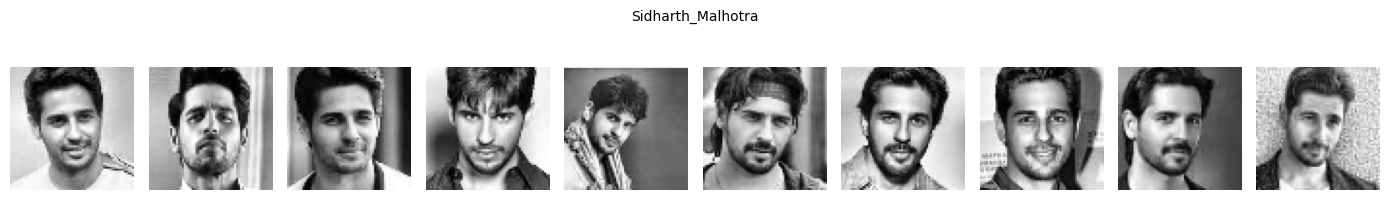

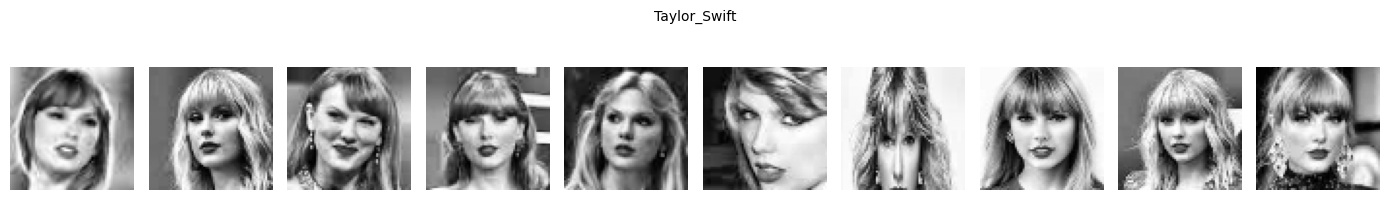

In [ ]:
# Diagnostic: check how many face detections succeeded per person & visualise the worst-looking crops so you know what the model saw

print("--- Face detection quality per person ---\n")
for p in persons:
    d = detection_log[p]
    total = d['detected'] + d['fallback']
    pct   = d['detected'] / total * 100 if total else 0
    bar   = "█" * d['detected'] + "░" * d['fallback']
    print(f"  {p:<12}  {d['detected']}/{total} detected  ({pct:.0f}%)  {bar}")

# Show all crops side by side so you can spot bad ones
print("\nAll training crops (check for blank/wrong crops):")
for person in persons:
    imgs = raw_images[person]
    fig, axes = plt.subplots(1, len(imgs), figsize=(len(imgs)*1.4, 2))
    for c, ax in enumerate(axes):
        if c < len(imgs):
            ax.imshow(imgs[c], cmap='gray')
        ax.axis('off')
    plt.suptitle(person, fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()